In [228]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import ChatHuggingFace, HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, BaseMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from dotenv import load_dotenv
from typing import Annotated, TypedDict

In [229]:
load_dotenv()

True

In [230]:
llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")

In [231]:
loader = PyPDFLoader("intro_to_ml.pdf")
docs = loader.load()

In [232]:
len(docs)

392

In [233]:
splitters = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitters.split_documents(docs)

In [234]:
len(chunks)

973

In [235]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vector_store = FAISS.from_documents(chunks, embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [236]:
vector_store

In [263]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [264]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [265]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [266]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [267]:
def chat_node(state: ChatState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [268]:
tool_node = ToolNode(tools)

In [272]:
graph = StateGraph(ChatState)

In [273]:
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

In [274]:
graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

In [275]:
chatbot = graph.compile()

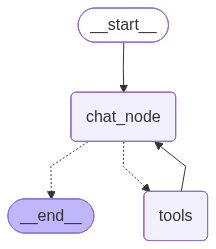

In [276]:
chatbot

In [277]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)




ValidationError: 1 validation error for Schema
properties.query
  Input should be a valid dictionary or object to extract fields from [type=model_attributes_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.12/v/model_attributes_type